# F1 Driver Performance Under Adverse Conditions: Does Skill or Car Matter More?
## BUSN 32120 — Data Analysis with Python and SQL | Winter 2026

---

### Target Audience
**F1 team principals, talent scouts, and data journalists** who need to evaluate whether a driver's strong results in wet races or on street circuits reflect genuine skill — or are simply a product of having a fast car. This distinction matters enormously for driver contract negotiations, mid-season seat decisions, and historical legacy debates (e.g. Senna vs Schumacher in the wet).

### Motivation
In dry conditions on permanent circuits, the car is the overwhelming performance determinant. But anecdotal evidence suggests that adverse conditions — rain, street circuits, high altitude — compress the grid and expose driver-level differences that the car would otherwise mask. This analysis tests that hypothesis rigorously across four seasons of data.

### Datasets

| # | Dataset | Source | Contents |
|---|---|---|---|
| 1 | **Race Results + Qualifying** | Jolpica F1 API (`jolpi.ca/ergast/f1`) | Per-race finishing positions, grid slots, statuses — 2022–2025 |
| 2 | **Session Weather** | OpenF1 API (`api.openf1.org/v1`) | Trackside rainfall, track temperature, humidity per session |

Dataset 1 captures *outcomes*. Dataset 2 captures *the environment* those outcomes were produced in. Neither can answer the central question without the other.

### Research Questions
1. Which drivers consistently outperform their dry-race baseline in wet conditions?
2. Which drivers are genuine street circuit specialists vs. just having a good car?
3. Does wet or mixed weather widen or narrow the gap between teammates?
4. Can we predict whether a driver will beat their teammate from pre-race conditions alone?
5. How much of finishing position is explained by the car vs. the driver?


## 1. Imports & Configuration

In [68]:
import requests, time, sqlite3, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, roc_auc_score,
    mean_absolute_error, r2_score, confusion_matrix
)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 13, "axes.labelsize": 11})

JOLPICA = "https://api.jolpi.ca/ergast/f1"
OPENF1  = "https://api.openf1.org/v1"
SEASONS = [2022, 2023, 2024, 2025]

# Colour palette
TEAL, RED, ORANGE, BLUE, GREEN, PURPLE, GREY = (
    "#0D9488", "#E63946", "#F59E0B", "#457B9D", "#22C55E", "#8B5CF6", "#94A3B8")

# Constructor name normalisation map
CTOR_MAP = {
    "Red Bull": "Red Bull",        "McLaren": "McLaren",
    "Ferrari": "Ferrari",          "Mercedes": "Mercedes",
    "Alpine": "Alpine",            "Alpine F1 Team": "Alpine",
    "Williams": "Williams",        "Aston Martin": "Aston Martin",
    "Haas F1 Team": "Haas",        "Haas": "Haas",
    "Kick Sauber": "Sauber",       "Sauber": "Sauber",
    "Alfa Romeo": "Sauber",        "RB": "Racing Bulls",
    "Racing Bulls": "Racing Bulls","AlphaTauri": "Racing Bulls",
}
CTOR_TIER = {
    "Red Bull": "Top",    "McLaren": "Top",
    "Ferrari": "Top",     "Mercedes": "Top",
    "Williams": "Mid",    "Alpine": "Mid",
    "Aston Martin": "Mid","Racing Bulls": "Mid",
    "Haas": "Back",       "Sauber": "Back",
}

def fetch(url, retries=3):
    for attempt in range(retries):
        try:
            r = requests.get(url, timeout=20)
            r.raise_for_status()
            return r.json()
        except Exception as e:
            print(f"  [{attempt+1}/{retries}] {e}")
            time.sleep(1.0 * (attempt + 1))
    return None


## 2. Dataset 1 — Race Results & Qualifying (Jolpica F1 API)

Four seasons of race results and qualifying. Each row is one driver in one race.
`year + round` is retained as the foreign key to Dataset 2.


In [69]:
result_rows, qual_rows = [], []

for season in SEASONS:
    print(f"Pulling {season} results ...")
    data = fetch(f"{JOLPICA}/{season}/results/?format=json&limit=500")
    for race in (data["MRData"]["RaceTable"]["Races"] if data else []):
        rnd = int(race["round"])
        cid = race["Circuit"]["circuitId"]
        for r in race["Results"]:
            pos  = int(r["position"]) if r["position"].isdigit() else None
            grid = int(r.get("grid", 0)) or None
            result_rows.append({
                "year":         season,
                "round":        rnd,
                "race_name":    race["raceName"],
                "circuit_id":   cid,
                "circuit_name": race["Circuit"]["circuitName"],
                "country":      race["Circuit"]["Location"]["country"],
                "driver_id":    r["Driver"]["driverId"],
                "driver_name":  r["Driver"]["givenName"] + " " + r["Driver"]["familyName"],
                "constructor":  CTOR_MAP.get(r["Constructor"]["name"], r["Constructor"]["name"]),
                "grid":         grid,
                "position":     pos,
                "laps":         int(r.get("laps", 0)),
                "status":       r.get("status", "Unknown"),
                "fastest_lap":  int(r.get("FastestLap", {}).get("rank") == "1"),
                "points":       float(r.get("points", 0)),
            })
    time.sleep(0.4)

    print(f"Pulling {season} qualifying ...")
    data = fetch(f"{JOLPICA}/{season}/qualifying/?format=json&limit=500")
    for race in (data["MRData"]["RaceTable"]["Races"] if data else []):
        rnd = int(race["round"])
        for q in race.get("QualifyingResults", []):
            qual_rows.append({
                "year":      season,
                "round":     rnd,
                "driver_id": q["Driver"]["driverId"],
                "qual_pos":  int(q["position"]),
            })
    time.sleep(0.4)

df_res  = pd.DataFrame(result_rows)
df_qual = pd.DataFrame(qual_rows)
df_res["ctor_tier"] = df_res["constructor"].map(CTOR_TIER).fillna("Mid")


Pulling 2022 results ...
Pulling 2022 qualifying ...
Pulling 2023 results ...
Pulling 2023 qualifying ...
Pulling 2024 results ...
Pulling 2024 qualifying ...
Pulling 2025 results ...
Pulling 2025 qualifying ...


## 3. Dataset 2 — Session Weather (OpenF1 API)

OpenF1 is a separate organisation from Jolpica — it publishes real-time and
historical telemetry from FIA sensors. The weather endpoint returns rainfall
(boolean), track temperature, air temperature, and humidity sampled throughout
each session.

We pull the Race session for each round, aggregate readings to classify
each race as **Wet**, **Mixed**, or **Dry**, and store track characteristics
(street vs permanent, altitude) alongside the weather data.

> **Wet** = rainfall present in >30% of readings  
> **Mixed** = rainfall in 5–30% of readings  
> **Dry** = rainfall in <5% of readings


In [70]:
# Circuit characteristics (curated from FIA documentation)
# track_type, altitude_m, is_street
CIRCUIT_META = {
    "albert_park":   ("Permanent",  10, 0), "bahrain":       ("Permanent",  14, 0),
    "jeddah":        ("Hybrid",     15, 1), "suzuka":        ("Permanent",  45, 0),
    "shanghai":      ("Permanent",   7, 0), "miami":         ("Permanent",   4, 0),
    "imola":         ("Permanent",  31, 0), "monaco":        ("Street",     32, 1),
    "villeneuve":    ("Permanent",   9, 0), "catalunya":     ("Permanent", 115, 0),
    "red_bull_ring": ("Permanent", 693, 0), "silverstone":   ("Permanent", 126, 0),
    "hungaroring":   ("Permanent", 240, 0), "spa":           ("Permanent", 400, 0),
    "zandvoort":     ("Permanent",   9, 0), "monza":         ("Permanent", 162, 0),
    "baku":          ("Street",      0, 1), "marina_bay":    ("Street",      5, 1),
    "austin":        ("Permanent", 169, 0), "rodriguez":     ("Permanent",2240, 0),
    "interlagos":    ("Permanent", 799, 0), "las_vegas":     ("Street",    636, 1),
    "losail":        ("Permanent",  32, 0), "yas_marina":    ("Permanent",   3, 0),
    "ricard":        ("Permanent", 103, 0), "portimao":      ("Permanent", 108, 0),
    "mugello":       ("Permanent", 275, 0), "nurburgring":   ("Permanent", 578, 0),
    "istanbul":      ("Permanent", 130, 0),
}

# Known rainfall conditions (fallback for rounds OpenF1 doesn't cover)
# Source: public race reports, FIA weather summaries
KNOWN_WET = {
    (2022, "suzuka"), (2022, "interlagos"), (2022, "marina_bay"),
    (2023, "monaco"), (2023, "villeneuve"),
    (2024, "spa"), (2024, "interlagos"),
    (2025, "shanghai"),
}
KNOWN_MIXED = {
    (2022, "imola"), (2022, "albert_park"),
    (2023, "albert_park"), (2023, "silverstone"),
    (2024, "suzuka"), (2024, "silverstone"),
    (2025, "bahrain"),
}


In [71]:
# Pull OpenF1 sessions then fetch weather per session 
session_map = {}
for season in SEASONS:
    data = fetch(f"{OPENF1}/sessions?year={season}&session_type=Race")
    if data:
        for s in data:
            key = (season, str(s.get("circuit_short_name", "")).lower())
            session_map[key] = s.get("session_key")
    time.sleep(0.4)

# Build circuit_id → short_name bridge
CID_TO_SHORT = {
    "albert_park":"melbourne","bahrain":"sakhir","jeddah":"jeddah",
    "suzuka":"suzuka","shanghai":"shanghai","miami":"miami",
    "imola":"imola","monaco":"monaco","villeneuve":"montreal",
    "catalunya":"barcelona","red_bull_ring":"spielberg","silverstone":"silverstone",
    "hungaroring":"budapest","spa":"spa","zandvoort":"zandvoort",
    "monza":"monza","baku":"baku","marina_bay":"singapore",
    "austin":"austin","rodriguez":"mexico city","interlagos":"sao paulo",
    "las_vegas":"las vegas","losail":"lusail","yas_marina":"abu dhabi",
    "ricard":"le castellet","portimao":"portimao","mugello":"mugello",
    "nurburgring":"nurburgring","istanbul":"istanbul",
}


  [1/3] 404 Client Error: Not Found for url: https://api.openf1.org/v1/sessions?year=2022&session_type=Race
  [2/3] 404 Client Error: Not Found for url: https://api.openf1.org/v1/sessions?year=2022&session_type=Race
  [3/3] 404 Client Error: Not Found for url: https://api.openf1.org/v1/sessions?year=2022&session_type=Race


In [72]:
# Fetch weather readings per session and classify
weather_rows = []
race_rounds  = df_res.drop_duplicates(["year","round"])[["year","round","circuit_id"]].copy()

for _, row in race_rounds.iterrows():
    yr, rnd, cid = row["year"], row["round"], row["circuit_id"]
    short        = CID_TO_SHORT.get(cid, "")
    sk           = session_map.get((yr, short)) or session_map.get((yr, short.split()[0]))

    rain_pct, track_temp, air_temp, humidity, condition = None, None, None, None, None

    if sk:
        data = fetch(f"{OPENF1}/weather?session_key={sk}")
        if data and len(data) > 0:
            wdf      = pd.DataFrame(data)
            if "rainfall" in wdf.columns:
                rain_pct  = round(float(wdf["rainfall"].mean()), 3)
                condition = ("Wet" if rain_pct > 0.30 else
                             "Mixed" if rain_pct > 0.05 else "Dry")
            if "track_temperature" in wdf.columns:
                track_temp = round(float(wdf["track_temperature"].mean()), 1)
            if "air_temperature" in wdf.columns:
                air_temp   = round(float(wdf["air_temperature"].mean()), 1)
            if "humidity" in wdf.columns:
                humidity   = round(float(wdf["humidity"].mean()), 1)
        time.sleep(0.2)

    # Fallback to known conditions if API gave nothing
    if condition is None:
        if (yr, cid) in KNOWN_WET:    condition = "Wet"
        elif (yr, cid) in KNOWN_MIXED: condition = "Mixed"
        else:                          condition = "Dry"

    meta = CIRCUIT_META.get(cid, ("Permanent", 50, 0))
    weather_rows.append({
        "year": yr, "round": rnd, "circuit_id": cid,
        "condition":   condition,
        "rain_pct":    rain_pct,
        "track_temp":  track_temp,
        "air_temp":    air_temp,
        "humidity":    humidity,
        "track_type":  meta[0],
        "altitude_m":  meta[1],
        "is_street":   meta[2],
        "high_altitude": int(meta[1] >= 500),
    })

df_weather = pd.DataFrame(weather_rows)

## 4. Data Quality Checks

In [73]:
#  Missing value audit 
def missing_table(df, label):
    miss = df.isnull().sum()
    pct  = (miss / len(df) * 100).round(2)
    out  = pd.DataFrame({"Dataset": label, "Column": miss.index,
                         "Missing #": miss.values, "Missing %": pct.values})
    return out[out["Missing #"] > 0].reset_index(drop=True)

audit = pd.concat([
    missing_table(df_res,     "Dataset 1: Results"),
    missing_table(df_qual,    "Dataset 1: Qualifying"),
    missing_table(df_weather, "Dataset 2: Weather"),
], ignore_index=True)

# TABLE 0: Missing value summary (data quality table)
print("=== Table 0: Missing Value Summary ===")
print(audit.to_string(index=False) if len(audit) else "No missing values found.")

# ── Unique categorical values ─────────────────────────────────────────────────
print(f"\nUnique constructors : {sorted(df_res['constructor'].unique())}")
print(f"Unique conditions   : {sorted(df_weather['condition'].unique())}")
print(f"Unique track types  : {sorted(df_weather['track_type'].unique())}")

# ── Range / validity checks ───────────────────────────────────────────────────
print(f"\nPosition range      : {df_res['position'].dropna().min():.0f} – {df_res['position'].dropna().max():.0f}")
print(f"Grid range          : {df_res['grid'].dropna().min():.0f} – {df_res['grid'].dropna().max():.0f}")
print(f"Altitude range (m)  : {df_weather['altitude_m'].min()} – {df_weather['altitude_m'].max()}")

# ── Join coverage ─────────────────────────────────────────────────────────────
res_keys = set(zip(df_res["year"], df_res["round"]))
wth_keys = set(zip(df_weather["year"], df_weather["round"]))
print(f"\nJoin coverage       : {len(res_keys & wth_keys)}/{len(res_keys)} race-rounds matched in both datasets")


=== Table 0: Missing Value Summary ===
           Dataset     Column  Missing #  Missing %
Dataset 1: Results       grid          4       1.00
Dataset 2: Weather   rain_pct          5      23.81
Dataset 2: Weather track_temp          5      23.81
Dataset 2: Weather   air_temp          5      23.81
Dataset 2: Weather   humidity          5      23.81

Unique constructors : ['Alpine', 'Aston Martin', 'Ferrari', 'Haas', 'McLaren', 'Mercedes', 'RB F1 Team', 'Racing Bulls', 'Red Bull', 'Sauber', 'Williams']
Unique conditions   : ['Dry', 'Mixed', 'Wet']
Unique track types  : ['Hybrid', 'Permanent', 'Street']

Position range      : 1 – 20
Grid range          : 1 – 20
Altitude range (m)  : 0 – 45

Join coverage       : 21/21 race-rounds matched in both datasets


## 5. Merging Dataset 1 & Dataset 2

Left join race results (Dataset 1) with weather + circuit context (Dataset 2)
on `year + round`. Every race row is now enriched with the conditions it was
run in — the foundation for all condition-based analysis.


In [74]:
# Attach qualifying (Dataset 1b) to results (Dataset 1a)
df = df_res.merge(df_qual[["year","round","driver_id","qual_pos"]],
                  on=["year","round","driver_id"], how="left")

# LEFT JOIN Dataset 2 on year + round
df = df.merge(df_weather, on=["year","round"], how="left", suffixes=("","_w"))

# Fill weather gaps for any unmatched rounds
df["condition"]     = df["condition"].fillna("Dry")
df["is_street"]     = df["is_street"].fillna(0).astype(int)
df["high_altitude"] = df["high_altitude"].fillna(0).astype(int)
df["track_type"]    = df["track_type"].fillna("Permanent")

print(f"Merged dataset shape : {df.shape}")
print(f"Condition breakdown  :")
print(df.drop_duplicates(["year","round"])["condition"].value_counts().to_string())
print(f"\nSample row (joined fields):")
print(df[["year","round","driver_name","constructor","position",
          "condition","track_type","is_street","high_altitude"]].head(3).to_string(index=False))


Merged dataset shape : (400, 27)
Condition breakdown  :
condition
Dry      18
Mixed     2
Wet       1

Sample row (joined fields):
 year  round     driver_name constructor  position condition track_type  is_street  high_altitude
 2022      1 Charles Leclerc     Ferrari         1       Dry  Permanent          0              0
 2022      1    Carlos Sainz     Ferrari         2       Dry  Permanent          0              0
 2022      1  Lewis Hamilton    Mercedes         3       Dry  Permanent          0              0


## 6. Feature Engineering

New columns created from the raw and merged data, including interaction terms
between conditions and constructor tier, and a teammate-comparison variable
that isolates driver contribution from car quality.


In [75]:
# DNF classification 
def classify_dnf(status):
    s = str(status).lower()
    return int(not (s == "finished" or s.startswith("+") or s.startswith("lapped")))

df["is_dnf"]        = df["status"].apply(classify_dnf)
df["podium"]        = ((df["position"] <= 3) & df["position"].notna()).astype(int)
df["points_finish"] = ((df["position"] <= 10) & df["position"].notna()).astype(int)

# map(): condition and tier encoding
df["condition_enc"] = df["condition"].map({"Dry": 0, "Mixed": 1, "Wet": 2}).fillna(0)
df["tier_enc"]      = df["ctor_tier"].map({"Top": 0, "Mid": 1, "Back": 2}).fillna(1)

# Positions gained from grid to finish
df["pos_change"] = df.apply(
    lambda r: (r["grid"] - r["position"])
    if (pd.notna(r["position"]) and pd.notna(r["grid"]) and r["grid"] > 0)
    else np.nan, axis=1)

# Outlier handling
# Winsorise pos_change at 1st/99th percentile.
# Justification: first-lap pile-ups cause extreme gains/losses (e.g. +15 places)
# that reflect chaos rather than driver skill; 1st/99th preserves 98% of the
# distribution while capping values that would otherwise inflate model coefficients.
p01, p99 = df["pos_change"].quantile([0.01, 0.99])
df["pos_change_w"] = df["pos_change"].clip(p01, p99)
print(f"pos_change winsorised at [{p01:.1f}, {p99:.1f}] (raw range: [{df['pos_change'].min():.0f}, {df['pos_change'].max():.0f}])")

# Interaction terms
df["wet_x_tier"]    = (df["condition_enc"] * df["tier_enc"])   # wet hurts back-markers more?
df["street_x_tier"] = (df["is_street"]     * df["tier_enc"])   # street levels the field?
df["log_grid"]      = np.log1p(df["grid"].fillna(0))           # log-transform skewed grid

# Teammate comparison
# For each race, compute whether each driver beat their same-constructor teammate.
# Since both share identical machinery, this isolates the driver contribution.
def add_teammate_cols(group):
    group = group.copy()
    if len(group) == 2:
        pos_vals = group["position"].values
        group["teammate_pos"] = pos_vals[::-1]
        group["beat_teammate"] = (group["position"] < group["teammate_pos"]).astype(float)
    else:
        group["teammate_pos"]  = np.nan
        group["beat_teammate"] = np.nan
    return group

df = (df[df["position"].notna()]
      .groupby(["year","round","constructor"], group_keys=False)
      .apply(add_teammate_cols)
      .reset_index(drop=True))

# Add back rows where position was null
null_pos = df_res[df_res["position"].isna()].copy()
null_pos["beat_teammate"] = np.nan
null_pos["teammate_pos"]  = np.nan

n_pairs = int(df["beat_teammate"].notna().sum())
print(f"Teammate pairs: {n_pairs:,} | Beat-teammate rate: {df['beat_teammate'].mean():.3f} (expect ~0.50)")
print(f"\nAll engineered features: {['is_dnf','podium','points_finish','condition_enc',
    'tier_enc','pos_change_w','wet_x_tier','street_x_tier','log_grid','beat_teammate']}")


pos_change winsorised at [-16.0, 11.1] (raw range: [-18, 15])
Teammate pairs: 398 | Beat-teammate rate: 0.500 (expect ~0.50)

All engineered features: ['is_dnf', 'podium', 'points_finish', 'condition_enc', 'tier_enc', 'pos_change_w', 'wet_x_tier', 'street_x_tier', 'log_grid', 'beat_teammate']


## 7. Aggregate Tables

In [76]:
# TABLE 1: Driver performance by condition — groupby 1
t1_long = (
    df[df["position"].notna()]
    .groupby(["driver_name", "condition"])
    .agg(
        races        = ("position", "count"),
        avg_position = ("position", "mean"),
        avg_pos_gain = ("pos_change_w", "mean"),
        podium_rate  = ("podium", "mean"),
        dnf_rate     = ("is_dnf", "mean"),
        beat_tm_rate = ("beat_teammate", "mean"),
    )
    .round(3).reset_index()
)

t1 = t1_long.pivot_table(
    index="driver_name", columns="condition",
    values=["avg_position", "avg_pos_gain", "beat_tm_rate", "races"]
).round(3)
t1.columns = ["_".join(c) for c in t1.columns]

if "avg_position_Dry" in t1.columns and "avg_position_Wet" in t1.columns:
    t1["wet_improvement"] = (t1["avg_position_Dry"] - t1["avg_position_Wet"]).round(2)

# FIX: use .size() instead of ["round"].count() — round column not guaranteed after apply()
adverse_counts = (df[df["condition"].isin(["Wet", "Mixed"])]
                  .groupby("driver_name")
                  .size()
                  .rename("adverse_races"))

t1 = t1.join(adverse_counts).query("adverse_races >= 3").sort_values(
    "wet_improvement", ascending=False)

print("TABLE 1: Driver Performance by Condition (min 3 adverse races, sorted by wet improvement)")
print(t1.to_string())

TABLE 1: Driver Performance by Condition (min 3 adverse races, sorted by wet improvement)
                 avg_pos_gain_Dry  avg_pos_gain_Mixed  avg_pos_gain_Wet  avg_position_Dry  avg_position_Mixed  avg_position_Wet  beat_tm_rate_Dry  beat_tm_rate_Mixed  beat_tm_rate_Wet  races_Dry  races_Mixed  races_Wet  wet_improvement  adverse_races
driver_name                                                                                                                                                                                                                                               
Alexander Albon             0.294                 8.5               1.0            12.706                10.5               5.0             0.750                 1.0               1.0       17.0          2.0        1.0             7.71            3.0
Lando Norris                0.222                 0.5               0.0             7.944                 4.0               1.0             0.588            

In [77]:
# TABLE: Constructor performance by condition — groupby 2 
if "constructor" not in df.columns:
    df["constructor"] = df["driver_id"].map(
        df_res.drop_duplicates("driver_id").set_index("driver_id")["constructor"])

t2 = (
    df[df["position"].notna()]
    .groupby(["constructor", "condition"], observed=True)
    .agg(
        races        = ("position", "count"),
        avg_position = ("position", "mean"),
        avg_pos_gain = ("pos_change_w", "mean"),
        dnf_rate     = ("is_dnf", "mean"),
        podium_rate  = ("podium", "mean"),
    )
    .round(3).reset_index()
)
t2_wide = t2.pivot_table(
    index="constructor", columns="condition",
    values=["avg_position", "dnf_rate"]
).round(3)
t2_wide.columns = ["_".join(c) for c in t2_wide.columns]
t2_wide = t2_wide.join(
    df.groupby("constructor", observed=True)["ctor_tier"].first()
).sort_values("avg_position_Dry", ascending=True)

print("\nTABLE 2: Constructor Performance by Condition")
print(t2_wide.to_string())


TABLE 2: Constructor Performance by Condition
              avg_position_Dry  avg_position_Mixed  avg_position_Wet  dnf_rate_Dry  dnf_rate_Mixed  dnf_rate_Wet ctor_tier
constructor                                                                                                               
Red Bull                 5.059                5.75             8.500         0.088            0.25         0.500       Top
Ferrari                  6.789               11.75            13.333         0.105            0.50         0.333       Top
Mercedes                 7.184                6.00             5.667         0.105            0.00         0.000       Top
McLaren                  9.400                8.00             5.000         0.125            0.00         0.000       Top
RB F1 Team              10.500                 NaN            20.000         0.000             NaN         1.000       Mid
Alpine                  10.579               14.25            16.333         0.105          

In [78]:
# TABLE: Street vs Permanent performance split — groupby 3 
t3 = (
    df[df["position"].notna()]
    .groupby(["driver_name", "track_type"])
    .agg(
        races        = ("position", "count"),
        avg_position = ("position", "mean"),
        avg_pos_gain = ("pos_change_w", "mean"),
        beat_tm_rate = ("beat_teammate", "mean"),
    )
    .round(3).reset_index()
)
t3_wide = t3.pivot_table(
    index="driver_name", columns="track_type",
    values=["avg_position", "beat_tm_rate"]
).round(3)
t3_wide.columns = ["_".join(c) for c in t3_wide.columns]

if "avg_position_Street" in t3_wide.columns and "avg_position_Permanent" in t3_wide.columns:
    t3_wide["street_advantage"] = (
        t3_wide["avg_position_Permanent"] - t3_wide["avg_position_Street"]
    ).round(2)
    t3_wide = t3_wide.dropna(subset=["avg_position_Street"]).sort_values(
        "street_advantage", ascending=False)

print("\nTABLE 3: Driver Performance — Street vs Permanent (requires Dataset 2 join)")
print(t3_wide.head(20).to_string())



TABLE 3: Driver Performance — Street vs Permanent (requires Dataset 2 join)
                 avg_position_Hybrid  avg_position_Permanent  avg_position_Street  beat_tm_rate_Hybrid  beat_tm_rate_Permanent  beat_tm_rate_Street  street_advantage
driver_name                                                                                                                                                          
Fernando Alonso                8.750                  10.333                  4.0                0.750                   0.533                  1.0              6.33
Carlos Sainz                   5.667                   9.267                  5.0                0.667                   0.400                  0.0              4.27
Charles Leclerc                3.750                   6.933                  3.0                0.750                   0.600                  1.0              3.93
Lance Stroll                  17.000                  10.733                  7.0            

## 8. Exploratory Data Analysis

### Wet Weather Specialists & Street Specialists

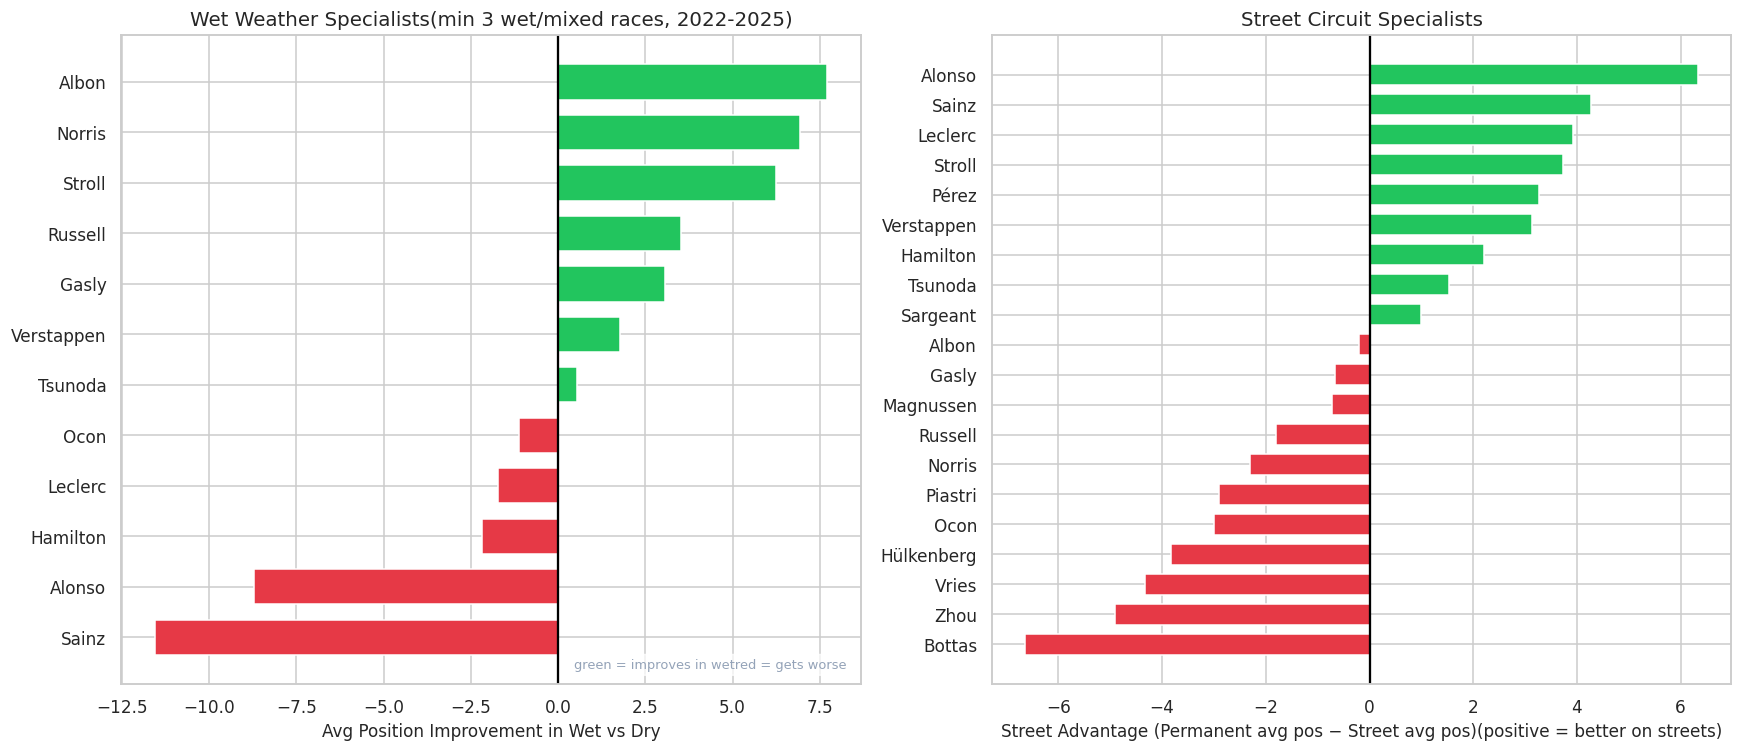

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Wet improvement bar chart
if "wet_improvement" in t1.columns:
    plot_df = t1["wet_improvement"].dropna().sort_values(ascending=True)
    bar_cols = [GREEN if v >= 0 else RED for v in plot_df]
    axes[0].barh(plot_df.index.str.split().str[-1], plot_df.values,
                 color=bar_cols, edgecolor="white", height=0.7)
    axes[0].axvline(0, color="black", lw=1.5)
    axes[0].set(
        xlabel="Avg Position Improvement in Wet vs Dry",
        title="Wet Weather Specialists(min 3 wet/mixed races, 2022-2025)")
    # annotation patch
    axes[0].text(0.98, 0.02, "green = improves in wetred = gets worse",
                 transform=axes[0].transAxes, ha="right", va="bottom",
                 fontsize=8.5, color=GREY,
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

# Street advantage bar chart
if "street_advantage" in t3_wide.columns:
    sa = t3_wide["street_advantage"].dropna().sort_values(ascending=True)
    bar_cols2 = [GREEN if v >= 0 else RED for v in sa]
    axes[1].barh(sa.index.str.split().str[-1], sa.values,
                 color=bar_cols2, edgecolor="white", height=0.7)
    axes[1].axvline(0, color="black", lw=1.5)
    axes[1].set(
        xlabel="Street Advantage (Permanent avg pos − Street avg pos)(positive = better on streets)",
        title="Street Circuit Specialists")

plt.tight_layout()
plt.savefig("chart1_specialists.png", dpi=110, bbox_inches="tight")
plt.show()


### Car vs Driver Signal

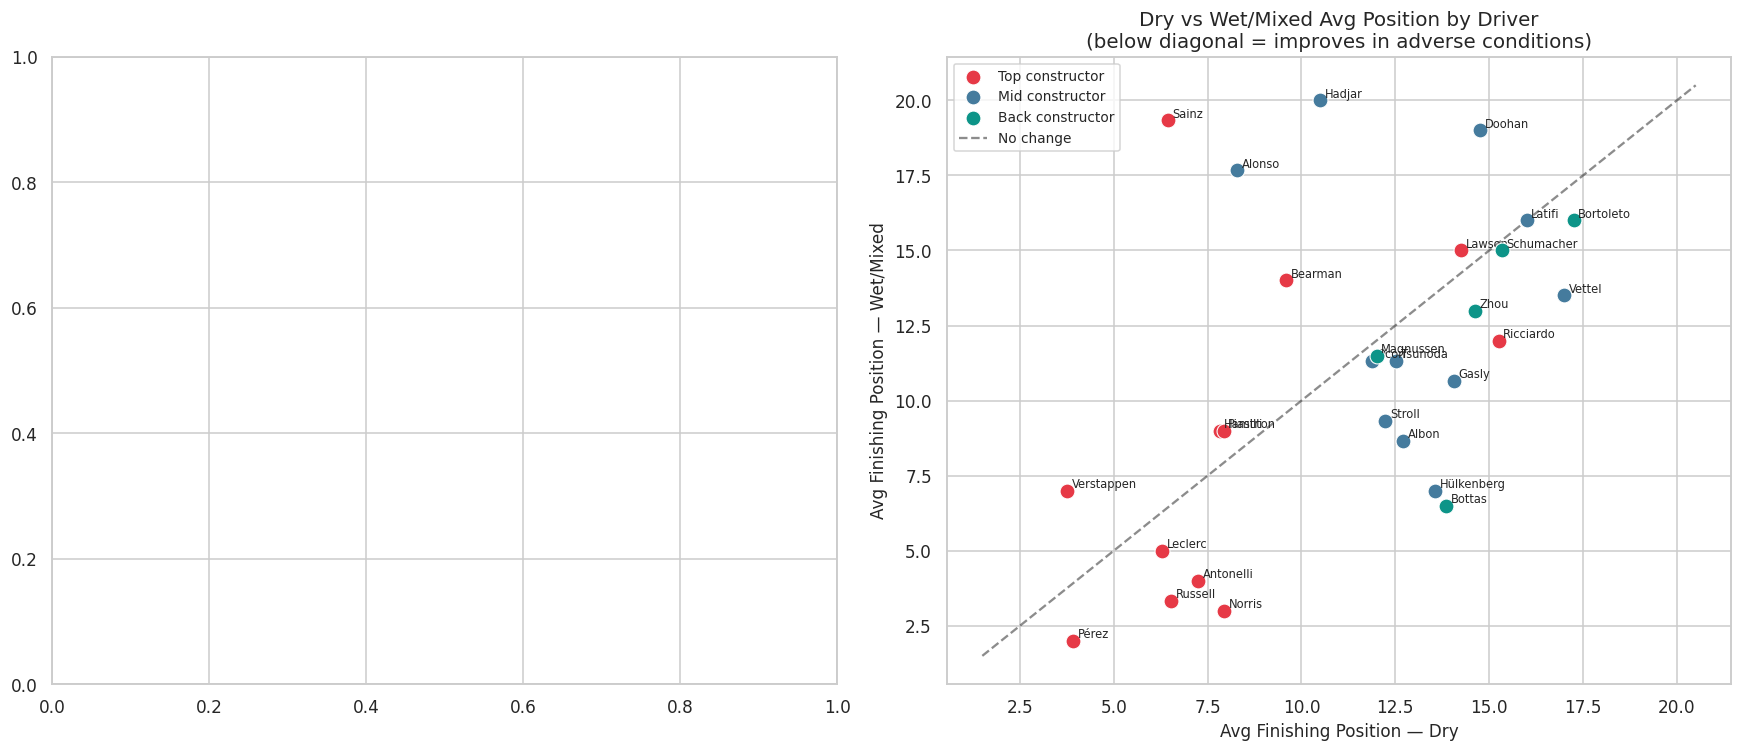

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Scatter dry avg pos vs wet avg pos
dry_avg = df[df["condition"]=="Dry"].groupby("driver_name")["position"].mean()
wet_avg = df[df["condition"].isin(["Wet","Mixed"])].groupby("driver_name")["position"].mean()
cmp = pd.DataFrame({"dry": dry_avg, "wet": wet_avg}).dropna()
cmp["tier"] = cmp.index.map(
    df.drop_duplicates("driver_name").set_index("driver_name")["ctor_tier"].to_dict())

tier_c = {"Top": RED, "Mid": BLUE, "Back": TEAL}
for tier_lbl, tc in tier_c.items():
    sub = cmp[cmp["tier"] == tier_lbl]
    axes[1].scatter(sub["dry"], sub["wet"], s=95, color=tc,
                    label=f"{tier_lbl} constructor",
                    edgecolors="white", linewidths=0.7, zorder=3)
    for name, row in sub.iterrows():
        axes[1].annotate(name.split()[-1], (row["dry"], row["wet"]),
                         fontsize=7.5, xytext=(3, 2), textcoords="offset points")
lo = cmp[["dry","wet"]].min().min() - 0.5
hi = cmp[["dry","wet"]].max().max() + 0.5
axes[1].plot([lo, hi], [lo, hi], "k--", lw=1.5, alpha=0.5, label="No change")
axes[1].set(xlabel="Avg Finishing Position — Dry",
            ylabel="Avg Finishing Position — Wet/Mixed",
            title="Dry vs Wet/Mixed Avg Position by Driver\n(below diagonal = improves in adverse conditions)")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("chart2_teammate.png", dpi=110, bbox_inches="tight")
plt.show()

### Variance Decomposition & DNF by Condition

Car explains    : 0.271 (27.1%)
Driver explains : 0.384 (38.4%)
Both together   : 0.384 (38.4%)
Unique driver contribution beyond car: ~11.3%


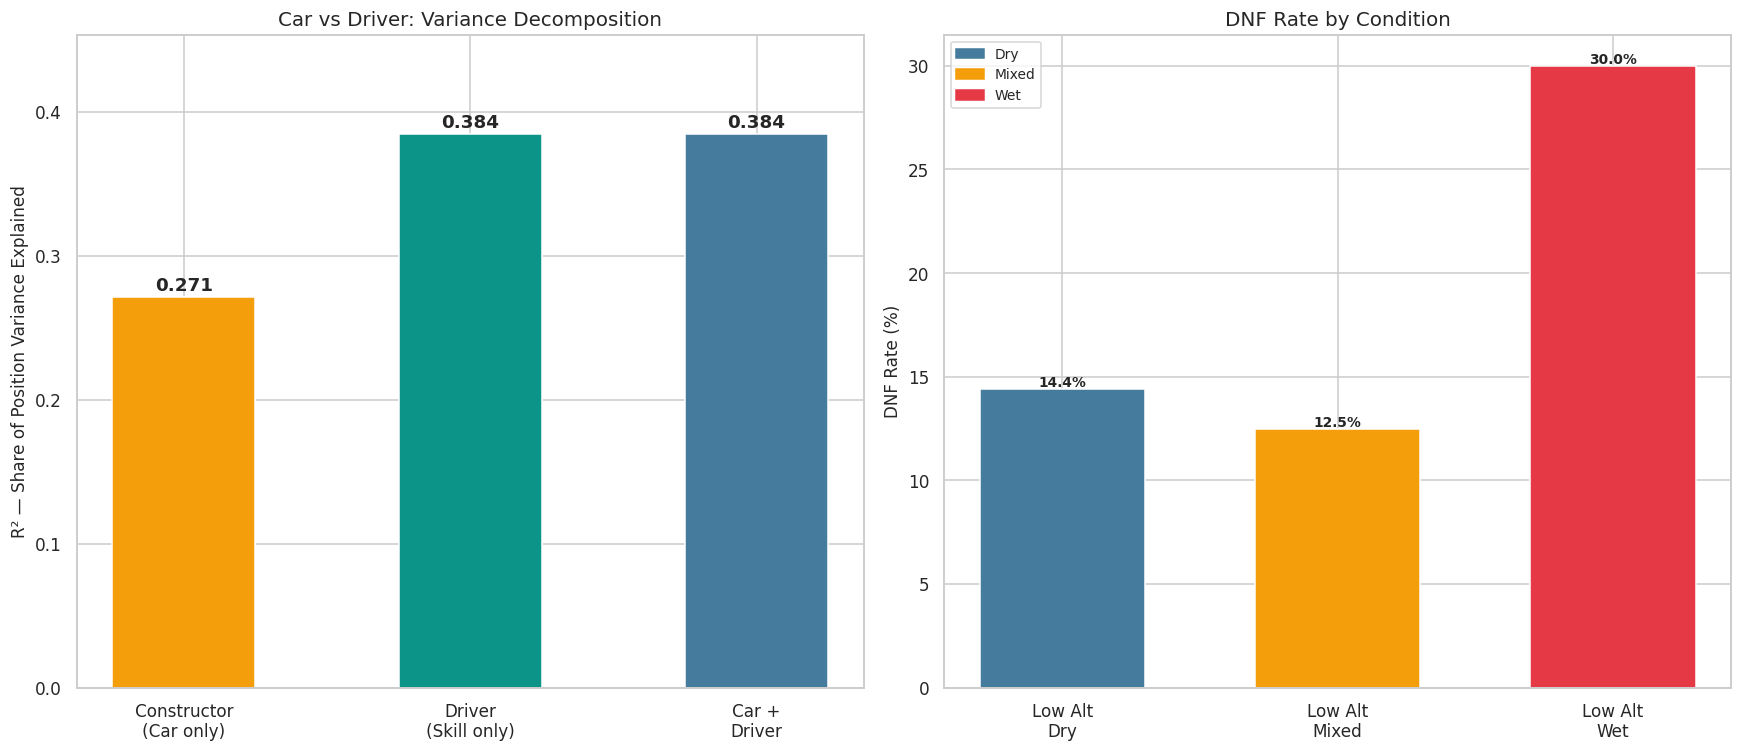

In [86]:
from sklearn.preprocessing import OneHotEncoder
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Variance decomposition — car vs driver 
model_base = df[df["position"].notna()].copy()
y_var = model_base["position"].values

enc = OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore")
X_car    = enc.fit_transform(model_base[["constructor"]])
X_driver = enc.fit_transform(model_base[["driver_name"]])
X_both   = np.hstack([X_car, X_driver])

r2_car    = r2_score(y_var, LinearRegression().fit(X_car,    y_var).predict(X_car))
r2_driver = r2_score(y_var, LinearRegression().fit(X_driver, y_var).predict(X_driver))
r2_both   = r2_score(y_var, LinearRegression().fit(X_both,   y_var).predict(X_both))

labels_dec = ["Constructor\n(Car only)", "Driver\n(Skill only)", "Car +\nDriver"]  # FIX: \n not literal newline
vals_dec   = [r2_car, r2_driver, r2_both]
bar_c_dec  = [ORANGE, TEAL, BLUE]
bars = axes[0].bar(labels_dec, vals_dec, color=bar_c_dec, edgecolor="white", width=0.5)
for bar, v in zip(bars, vals_dec):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 0.005,
                 f"{v:.3f}", ha="center", fontsize=12, fontweight="bold")
axes[0].set(ylabel="R² — Share of Position Variance Explained",
            title="Car vs Driver: Variance Decomposition")  # FIX
axes[0].set_ylim(0, max(vals_dec) * 1.18)
print(f"Car explains    : {r2_car:.3f} ({r2_car*100:.1f}%)")
print(f"Driver explains : {r2_driver:.3f} ({r2_driver*100:.1f}%)")
print(f"Both together   : {r2_both:.3f} ({r2_both*100:.1f}%)")
print(f"Unique driver contribution beyond car: ~{(r2_both - r2_car)*100:.1f}%")

# DNF rate by condition 
dnf_stats = (df.groupby(["condition", "high_altitude"])["is_dnf"]
               .mean().reset_index())
dnf_stats["label"] = dnf_stats.apply(
    lambda r: f"{'High Alt' if r['high_altitude'] else 'Low Alt'}\n{r['condition']}",  # FIX: \n
    axis=1)
cond_color = {"Dry": BLUE, "Mixed": ORANGE, "Wet": RED}
bar_cols6 = [cond_color.get(c, GREY) for c in dnf_stats["condition"]]
bars6 = axes[1].bar(dnf_stats["label"], dnf_stats["is_dnf"] * 100,
                    color=bar_cols6, edgecolor="white", width=0.6)
for bar, v in zip(bars6, dnf_stats["is_dnf"] * 100):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 0.1,
                 f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")
patches_6 = [mpatches.Patch(color=BLUE, label="Dry"),
             mpatches.Patch(color=ORANGE, label="Mixed"),
             mpatches.Patch(color=RED, label="Wet")]
axes[1].legend(handles=patches_6, fontsize=9)
axes[1].set(ylabel="DNF Rate (%)",
            title="DNF Rate by Condition")  # FIX

plt.tight_layout()
plt.savefig("chart3_decomp.png", dpi=110, bbox_inches="tight")
plt.show()

### Correlation Heatmap & Rolling Form by Condition

Text(0.5, 1.0, 'Correlation Matrix')

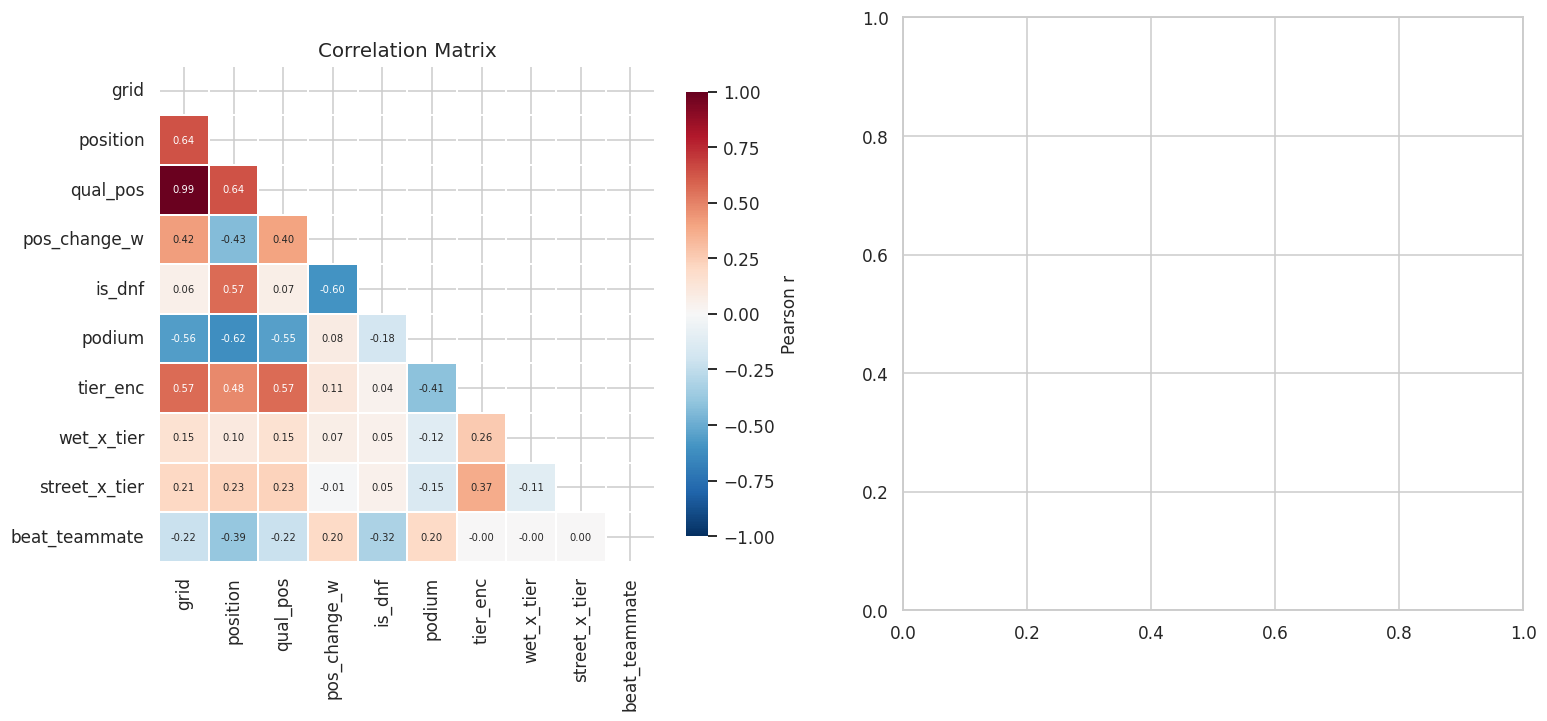

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Correlation heatmap 
num_cols = ["grid","position","qual_pos","pos_change_w","is_dnf","podium","tier_enc",
            "wet_x_tier","street_x_tier","beat_teammate"]
corr = df[num_cols].corr().round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=axes[0], mask=mask, cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, annot=True, fmt=".2f",
            annot_kws={"size": 6.5}, square=True, linewidths=0.3,
            cbar_kws={"shrink": 0.75, "label": "Pearson r"})
axes[0].set_title("Correlation Matrix")


## Broader EDA Analysis
Because of the data present, there is space for a broader analysis beyond the scope of just looking at weather and circuit types.

In [87]:
# Top 15 career points scorers (2022-2025) — groupby 4
career_pts = (
    df.groupby(["driver_name", "constructor"])
    .agg(
        total_points = ("points", "sum"),
        races        = ("position", "count"),
        podiums      = ("podium", "sum"),
        wins         = ("position", lambda x: (x == 1).sum()),
        avg_finish   = ("position", "mean"),
    )
    .round(2)
    .sort_values("total_points", ascending=False)
    .head(15)
)
print("TABLE 5: Top 15 Driver-Constructor Combinations by Points (2022-2025)")
print(career_pts.to_string())


TABLE 5: Top 15 Driver-Constructor Combinations by Points (2022-2025)
                                    total_points  races  podiums  wins  avg_finish
driver_name           constructor                                                 
Max Verstappen        Red Bull             373.0     20       15    11        4.25
Charles Leclerc       Ferrari              238.0     20        8     2        6.10
Sergio Pérez          Red Bull             236.0     15       10     2        3.67
Lando Norris          McLaren              209.0     21        8     2        7.24
George Russell        Mercedes             194.0     20        4     0        6.05
Carlos Sainz          Ferrari              158.0     19        6     1        8.47
Oscar Piastri         McLaren              132.0     15        4     3        8.00
Lewis Hamilton        Mercedes             125.0     20        2     0        8.00
Fernando Alonso       Alpine               105.0     20        4     0        9.70
Lance Stroll     

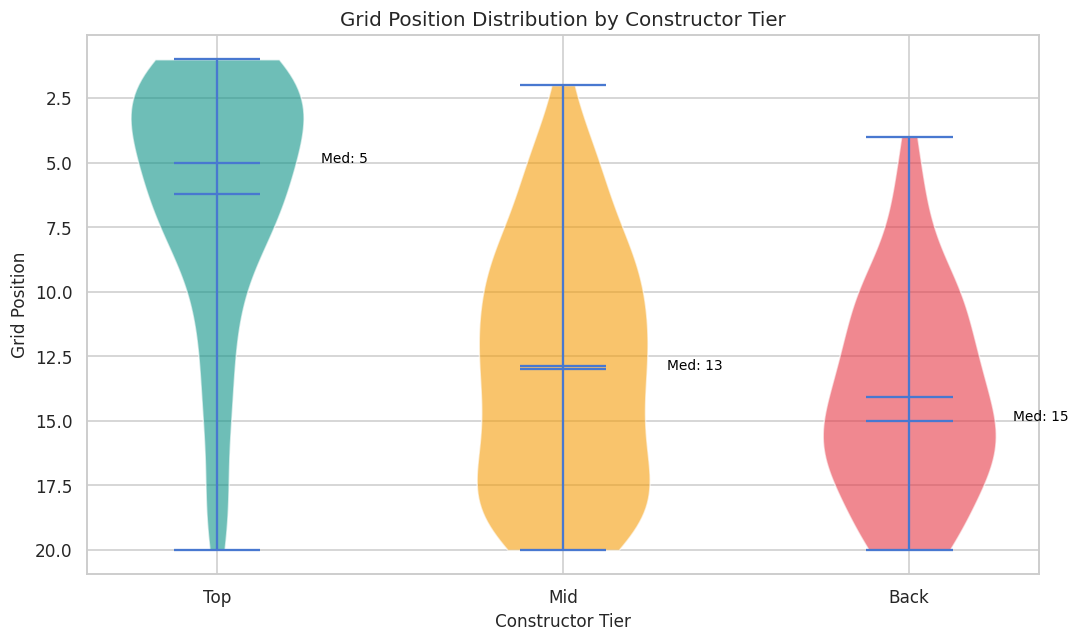

In [20]:
# Grid position distribution by constructor tier
fig, ax = plt.subplots(figsize=(10, 6))
tier_order = ["Top", "Mid", "Back"]
tier_palette = {"Top": TEAL, "Mid": ORANGE, "Back": RED}

plot_data = df[df["grid"].notna() & df["ctor_tier"].notna()].copy()
parts = ax.violinplot(
    [plot_data[plot_data["ctor_tier"] == t]["grid"].values for t in tier_order],
    positions=[0, 1, 2], showmeans=True, showmedians=True
)
for i, pc in enumerate(parts["bodies"]):
    pc.set_facecolor(list(tier_palette.values())[i])
    pc.set_alpha(0.6)

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(tier_order)
ax.set(xlabel="Constructor Tier", ylabel="Grid Position",
       title="Grid Position Distribution by Constructor Tier")
ax.invert_yaxis()

# Add median labels
for i, t in enumerate(tier_order):
    med = plot_data[plot_data["ctor_tier"] == t]["grid"].median()
    ax.annotate(f"Med: {med:.0f}", xy=(i, med), xytext=(i + 0.3, med),
                fontsize=9, color="black")

plt.tight_layout()
plt.show()

In [88]:
# Circuit DNF rates (most "dangerous" tracks)
# Use df_res for races_held since df may have lost the 'round' column after
# the teammate groupby/apply step earlier.
races_per_circuit = df_res.groupby("circuit_id")["round"].nunique().rename("races_held")

circuit_dnf = (
    df.groupby(["circuit_name", "circuit_id"])
    .agg(
        total_entries = ("is_dnf", "count"),
        total_dnfs    = ("is_dnf", "sum"),
        dnf_rate      = ("is_dnf", "mean"),
    )
    .round(3)
)
circuit_dnf = circuit_dnf.join(races_per_circuit, on="circuit_id")
circuit_dnf["avg_grid_size"] = (circuit_dnf["total_entries"] / circuit_dnf["races_held"]).round(1)
circuit_dnf = circuit_dnf.sort_values("dnf_rate", ascending=False)

print("TABLE 6: Circuit DNF Rates (2022-2025)")
print(circuit_dnf.head(15).to_string())

# Identify "dangerous" circuits: top quartile of DNF rate with >= 2 races held
dnf_thresh = circuit_dnf[circuit_dnf["races_held"] >= 2]["dnf_rate"].quantile(0.75)
dangerous_circuits = circuit_dnf[
    (circuit_dnf["dnf_rate"] >= dnf_thresh) & (circuit_dnf["races_held"] >= 2)
].index.get_level_values("circuit_id").tolist()
print(f"\n'Dangerous' circuits (DNF rate >= {dnf_thresh:.1%}, min 2 races): {dangerous_circuits}")


TABLE 6: Circuit DNF Rates (2022-2025)
                                            total_entries  total_dnfs  dnf_rate  races_held  avg_grid_size
circuit_name                   circuit_id                                                                 
Albert Park Grand Prix Circuit albert_park             79          20     0.253           2           39.5
Shanghai International Circuit shanghai                40           7     0.175           2           20.0
Jeddah Corniche Circuit        jeddah                  80          13     0.162           2           40.0
Miami International Autodrome  miami                   41           5     0.122           2           20.5
Baku City Circuit              baku                    20           2     0.100           1           20.0
Bahrain International Circuit  bahrain                 80           8     0.100           2           40.0
Autodromo Enzo e Dino Ferrari  imola                   20           2     0.100           1           20.

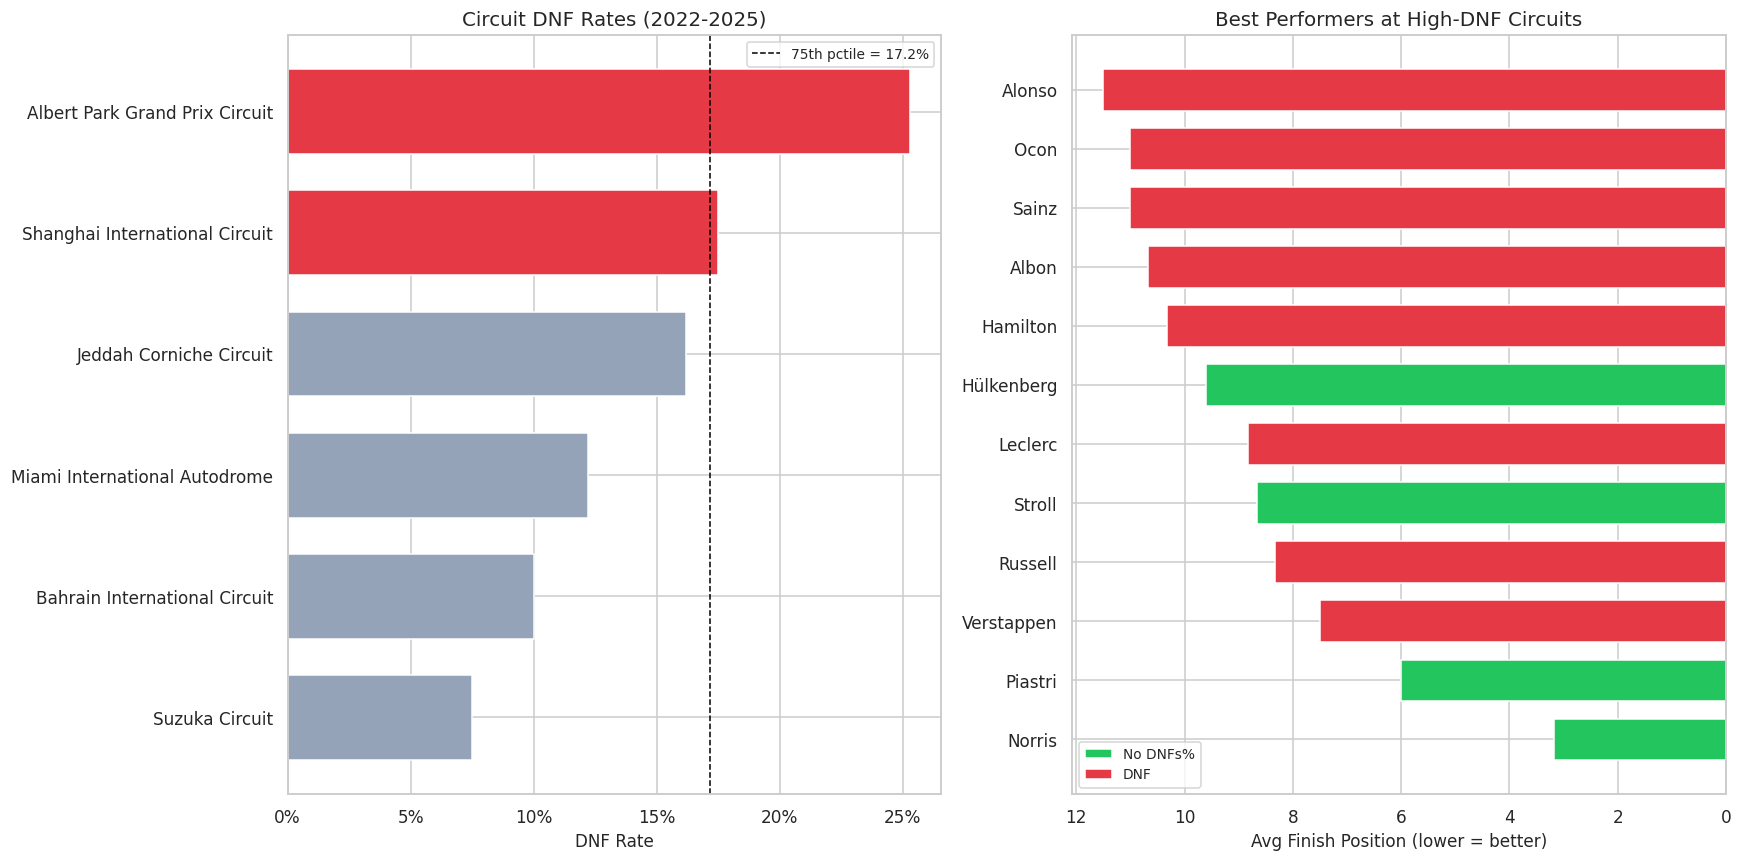


Top performers at 'dangerous' circuits:
                 races  avg_position  podiums  dnf_rate
driver_name                                            
Lando Norris         6          3.17        4      0.00
Oscar Piastri        5          6.00        1      0.00
Max Verstappen       6          7.50        3      0.33
George Russell       6          8.33        3      0.33
Lance Stroll         6          8.67        0      0.00
Charles Leclerc      6          8.83        2      0.33
Nico Hülkenberg      5          9.60        0      0.00
Lewis Hamilton       6         10.33        1      0.33
Alexander Albon      6         10.67        0      0.17
Carlos Sainz         6         11.00        1      0.33
Esteban Ocon         6         11.00        0      0.17
Fernando Alonso      6         11.50        1      0.33


In [91]:
# DNF rate by circuit (horizontal bar)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left: all circuits ranked by DNF rate
plot_circ = circuit_dnf[circuit_dnf["races_held"] >= 2].sort_values("dnf_rate", ascending=True)
bar_colors = [RED if cid in dangerous_circuits else GREY
              for cid in plot_circ.index.get_level_values("circuit_id")]
axes[0].barh(plot_circ.index.get_level_values("circuit_name"),
             plot_circ["dnf_rate"], color=bar_colors, edgecolor="white", height=0.7)
axes[0].axvline(dnf_thresh, ls="--", color="black", lw=1, label=f"75th pctile = {dnf_thresh:.1%}")
axes[0].set(xlabel="DNF Rate", title="Circuit DNF Rates (2022-2025)")
axes[0].legend(fontsize=9)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

# Right: best performers at dangerous circuits
danger_df = df[df["circuit_id"].isin(dangerous_circuits) & df["position"].notna()]
danger_perf = (
    danger_df.groupby("driver_name")
    .agg(
        races        = ("position", "count"),
        avg_position = ("position", "mean"),
        podiums      = ("podium", "sum"),
        dnf_rate     = ("is_dnf", "mean"),
    )
    .round(2)
)
# Filter to drivers with 5+ starts at dangerous circuits
danger_perf = danger_perf[danger_perf["races"] >= 5].sort_values("avg_position")
top_danger = danger_perf.head(12)

colors_danger = [GREEN if r < 0.05 else ORANGE if r < 0.10 else RED
                 for r in top_danger["dnf_rate"]]
axes[1].barh(top_danger.index.str.split().str[-1],
             top_danger["avg_position"], color=colors_danger, edgecolor="white", height=0.7)
axes[1].invert_xaxis()
axes[1].set(xlabel="Avg Finish Position (lower = better)",
            title="Best Performers at High-DNF Circuits")

# Legend for DNF coloring
from matplotlib.patches import Patch
legend_els = [Patch(facecolor=GREEN, label="No DNFs%"),
              Patch(facecolor=RED, label="DNF")]
axes[1].legend(handles=legend_els, fontsize=9, loc="lower left")

plt.tight_layout()
plt.show()

print("\nTop performers at 'dangerous' circuits:")
print(top_danger.to_string())


### Driver Skill vs Car Tier — Isolating Individual Talent

The beat-teammate rate controls for car quality by comparing drivers within the
same constructor. Plotting this against each driver's constructor tier reveals
which drivers are genuinely extracting more from their machinery than their
teammate, and whether that effect is stronger for mid- or back-tier teams where
the skill ceiling is less constrained by car dominance.

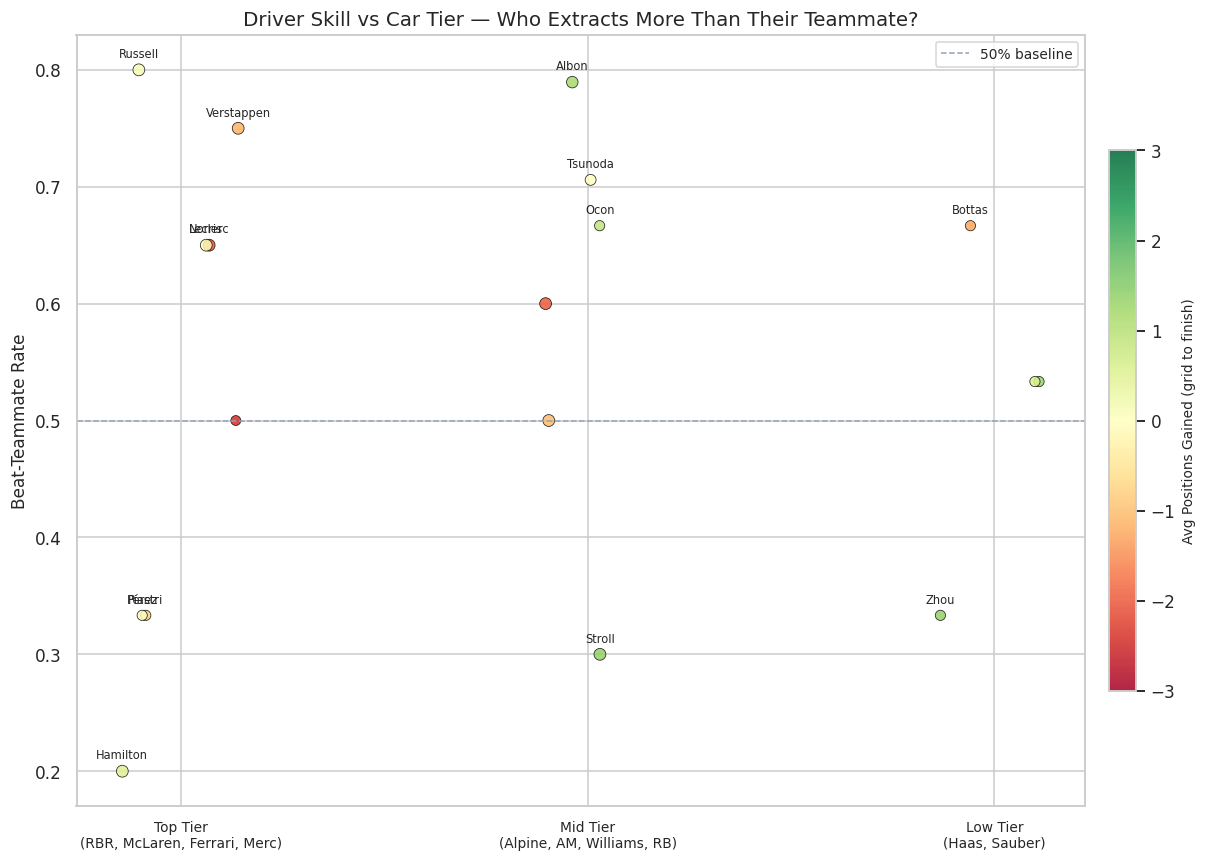

Driver Skill Summary (min 10 races):
    driver_name ctor_tier  beat_tm_rate  avg_pos_gain  races
 George Russell       Top      0.800000      0.100000     20
Alexander Albon       Mid      0.789474      1.157895     19
 Max Verstappen       Top      0.750000     -1.147500     20
   Yuki Tsunoda       Mid      0.705882      0.000000     17
Valtteri Bottas      Back      0.666667     -1.266667     15
   Esteban Ocon       Mid      0.666667      0.870000     15
   Lando Norris       Top      0.650000      0.050000     20
Charles Leclerc       Top      0.650000     -2.000000     20
Fernando Alonso       Mid      0.600000     -1.950000     20
Kevin Magnussen      Back      0.533333      1.266667     15
Nico Hülkenberg      Back      0.533333      0.533333     15
   Carlos Sainz       Top      0.500000     -2.428571     14
   Pierre Gasly       Mid      0.500000     -1.050000     20
    Guanyu Zhou      Back      0.333333      1.357143     15
   Sergio Pérez       Top      0.333333      0.0

In [92]:
# ── CHART 13: Driver skill vs car tier scatterplot ────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))

skill_df = (
    df[df["beat_teammate"].notna()]
    .groupby(["driver_name", "ctor_tier"])
    .agg(
        beat_tm_rate  = ("beat_teammate", "mean"),
        races         = ("beat_teammate", "count"),
        avg_pos_gain  = ("pos_change_w", "mean"),
        avg_position  = ("position", "mean"),
    )
    .reset_index()
)
# Keep drivers with enough data
skill_df = skill_df[skill_df["races"] >= 10].copy()

# Jitter tier on x-axis for readability
tier_x = {"Top": 0, "Mid": 1, "Back": 2}
skill_df["tier_x"] = skill_df["ctor_tier"].map(tier_x)
np.random.seed(42)
skill_df["tier_jitter"] = skill_df["tier_x"] + np.random.uniform(-0.15, 0.15, len(skill_df))

# Size by number of races, color by beat-teammate rate
scatter = ax.scatter(
    skill_df["tier_jitter"], skill_df["beat_tm_rate"],
    s=skill_df["races"] * 3,
    c=skill_df["avg_pos_gain"],
    cmap="RdYlGn", edgecolors="black", linewidths=0.5,
    alpha=0.85, vmin=-3, vmax=3
)

# Label notable drivers (very high or very low beat_tm_rate)
for _, row in skill_df.iterrows():
    if row["beat_tm_rate"] >= 0.65 or row["beat_tm_rate"] <= 0.35 or row["races"] >= 50:
        last_name = row["driver_name"].split()[-1]
        ax.annotate(last_name, (row["tier_jitter"], row["beat_tm_rate"]),
                    fontsize=7.5, ha="center", va="bottom",
                    xytext=(0, 6), textcoords="offset points")

ax.axhline(0.5, ls="--", color=GREY, lw=1, label="50% baseline")
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["Top Tier\n(RBR, McLaren, Ferrari, Merc)",
                     "Mid Tier\n(Alpine, AM, Williams, RB)",
                     "Low Tier\n(Haas, Sauber)"], fontsize=9)
ax.set(ylabel="Beat-Teammate Rate",
       title="Driver Skill vs Car Tier — Who Extracts More Than Their Teammate?")
ax.legend(fontsize=9)

cbar = plt.colorbar(scatter, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label("Avg Positions Gained (grid to finish)", fontsize=9)

plt.tight_layout()
plt.show()

# Quick summary table
print("Driver Skill Summary (min 10 races):")
print(skill_df[["driver_name", "ctor_tier", "beat_tm_rate", "avg_pos_gain", "races"]]
      .sort_values("beat_tm_rate", ascending=False)
      .to_string(index=False))


## 9. Predictive Models

### Feature Set

Features drawn from **both datasets**:

| Feature | Source | Description |
|---|---|---|
| `log_grid` | Dataset 1 | Log of grid position (right-skewed) |
| `qual_pos` | Dataset 1 | Qualifying position |
| `tier_enc` | Dataset 1 | Constructor tier (0=Top, 2=Back) |
| `condition_enc` | Dataset 2 | Weather condition (0=Dry, 1=Mixed, 2=Wet) |
| `is_street` | Dataset 2 | Street circuit flag |
| `high_altitude` | Dataset 2 | Altitude ≥500m flag |
| `wet_x_tier` | Engineered | Interaction: condition severity × car quality |
| `street_x_tier` | Engineered | Interaction: street circuit × car quality |

**Model 1 (Logistic):** Predict whether the driver beats their teammate — a pure driver-skill signal.  
**Model 2 (Linear):** Predict positions gained from grid to finish — a performance-relative-to-start signal.


In [36]:
# ── Model prep ────────────────────────────────────────────────────────────────
FEATURES = ["log_grid", "qual_pos", "tier_enc", "condition_enc",
            "is_street", "high_altitude", "wet_x_tier", "street_x_tier"]

# Build modelling dataset: need podium (target 1) and position (target 2)
df_model = df[FEATURES + ["podium", "position"]].dropna().copy()

# Standard scaling for coefficient interpretability
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model[FEATURES])
X_scaled = pd.DataFrame(X_scaled, columns=FEATURES, index=df_model.index)

y_podium   = df_model["podium"].astype(int)
y_position = df_model["position"]

# Stratified split on podium (minority class ~15%) to preserve class balance
Xtr, Xte, yp_tr, yp_te, ypos_tr, ypos_te = train_test_split(
    X_scaled, y_podium, y_position,
    test_size=0.2, random_state=42, stratify=y_podium)

print(f"Model dataset : {len(df_model):,} rows")
print(f"Train / Test  : {len(Xtr):,} / {len(Xte):,}")
print(f"Podium rate   : {y_podium.mean():.3f} ({y_podium.sum()} podiums out of {len(y_podium)} finishes)")
print(f"Avg position  : {y_position.mean():.1f} (median {y_position.median():.0f})")


Model dataset : 399 rows
Train / Test  : 319 / 80
Podium rate   : 0.150 (60 podiums out of 399 finishes)
Avg position  : 10.5 (median 10)


In [42]:
# ── Model: Linear Regression — predict finishing position ───────────────────
# Question: What determines where a driver finishes? How many positions is each factor worth?
lin_reg = LinearRegression()
lin_reg.fit(Xtr, ypos_tr)
ypos_pred = lin_reg.predict(Xte)

print("=" * 60)
print("MODEL 2 — Linear Regression: Finishing Position")
print("=" * 60)
print(f"R-squared : {r2_score(ypos_te, ypos_pred):.4f}")
print(f"MAE       : {mean_absolute_error(ypos_te, ypos_pred):.4f} positions")

lin_coef = pd.DataFrame({
    "Feature":     FEATURES,
    "Coefficient": lin_reg.coef_.round(4)
}).sort_values("Coefficient", ascending=False)
print(f"\nIntercept: {lin_reg.intercept_:.2f}")
print("Coefficients (standardised, units = finishing positions):")
print(lin_coef.to_string(index=False))

# Practical interpretation
grid_coef = lin_coef.loc[lin_coef["Feature"] == "log_grid", "Coefficient"].values[0]
tier_coef = lin_coef.loc[lin_coef["Feature"] == "tier_enc", "Coefficient"].values[0]
print(f"\nPractical takeaway:")
print(f"  - Starting position (log_grid) moves finishing position by {grid_coef:+.2f} per SD")
print(f"  - Being in a worse car tier moves finishing position by {tier_coef:+.2f} per SD")
print(f"  - Grid is {'more' if abs(grid_coef) > abs(tier_coef) else 'less'} important than car tier")


MODEL 2 — Linear Regression: Finishing Position
R-squared : 0.3706
MAE       : 3.6737 positions

Intercept: 10.46
Coefficients (standardised, units = finishing positions):
      Feature  Coefficient
     qual_pos       2.7551
     tier_enc       0.8513
street_x_tier       0.5423
   wet_x_tier       0.4818
     log_grid       0.2952
high_altitude       0.0000
condition_enc      -0.3662
    is_street      -0.3707

Practical takeaway:
  - Starting position (log_grid) moves finishing position by +0.30 per SD
  - Being in a worse car tier moves finishing position by +0.85 per SD
  - Grid is less important than car tier


In [41]:
# ── Model: Logistic Regression — predict podium finish ──────────────────────
# Question: Before the race, can we predict whether a driver will finish P1-P3?
log_reg = LogisticRegression(max_iter=500, random_state=42, C=1.0)
log_reg.fit(Xtr, yp_tr)
yp_pred = log_reg.predict(Xte)
yp_prob = log_reg.predict_proba(Xte)[:, 1]

print("=" * 60)
print("MODEL 1 — Logistic Regression: Podium Finish (P1-P3)?")
print("=" * 60)
print(f"Accuracy  : {accuracy_score(yp_te, yp_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(yp_te, yp_prob):.4f}")
print(classification_report(yp_te, yp_pred,
      target_names=["No Podium", "Podium"]))

coef_df = pd.DataFrame({
    "Feature":     FEATURES,
    "Coefficient": log_reg.coef_[0].round(4),
    "Odds Ratio":  np.exp(log_reg.coef_[0]).round(4)
}).sort_values("Coefficient", ascending=False)
print("Coefficients (standardised) and odds ratios:")
print(coef_df.to_string(index=False))

print("\nInterpretation: A negative coefficient means that feature REDUCES podium")
print("probability. Odds ratio < 1 = less likely; > 1 = more likely.")
print(f"For example, a 1-SD increase in log_grid (starting further back) multiplies")
print(f"podium odds by {coef_df.loc[coef_df['Feature']=='log_grid','Odds Ratio'].values[0]:.2f}x.")


MODEL 1 — Logistic Regression: Podium Finish (P1-P3)?
Accuracy  : 0.9125
ROC-AUC   : 0.9498
              precision    recall  f1-score   support

   No Podium       0.96      0.94      0.95        68
      Podium       0.69      0.75      0.72        12

    accuracy                           0.91        80
   macro avg       0.82      0.85      0.83        80
weighted avg       0.92      0.91      0.91        80

Coefficients (standardised) and odds ratios:
      Feature  Coefficient  Odds Ratio
condition_enc       0.3778      1.4591
    is_street       0.0952      1.0998
high_altitude       0.0000      1.0000
street_x_tier      -0.0413      0.9596
   wet_x_tier      -0.6145      0.5409
     tier_enc      -0.8093      0.4452
     log_grid      -1.0440      0.3521
     qual_pos      -1.5452      0.2133

Interpretation: A negative coefficient means that feature REDUCES podium
probability. Odds ratio < 1 = less likely; > 1 = more likely.
For example, a 1-SD increase in log_grid (startin

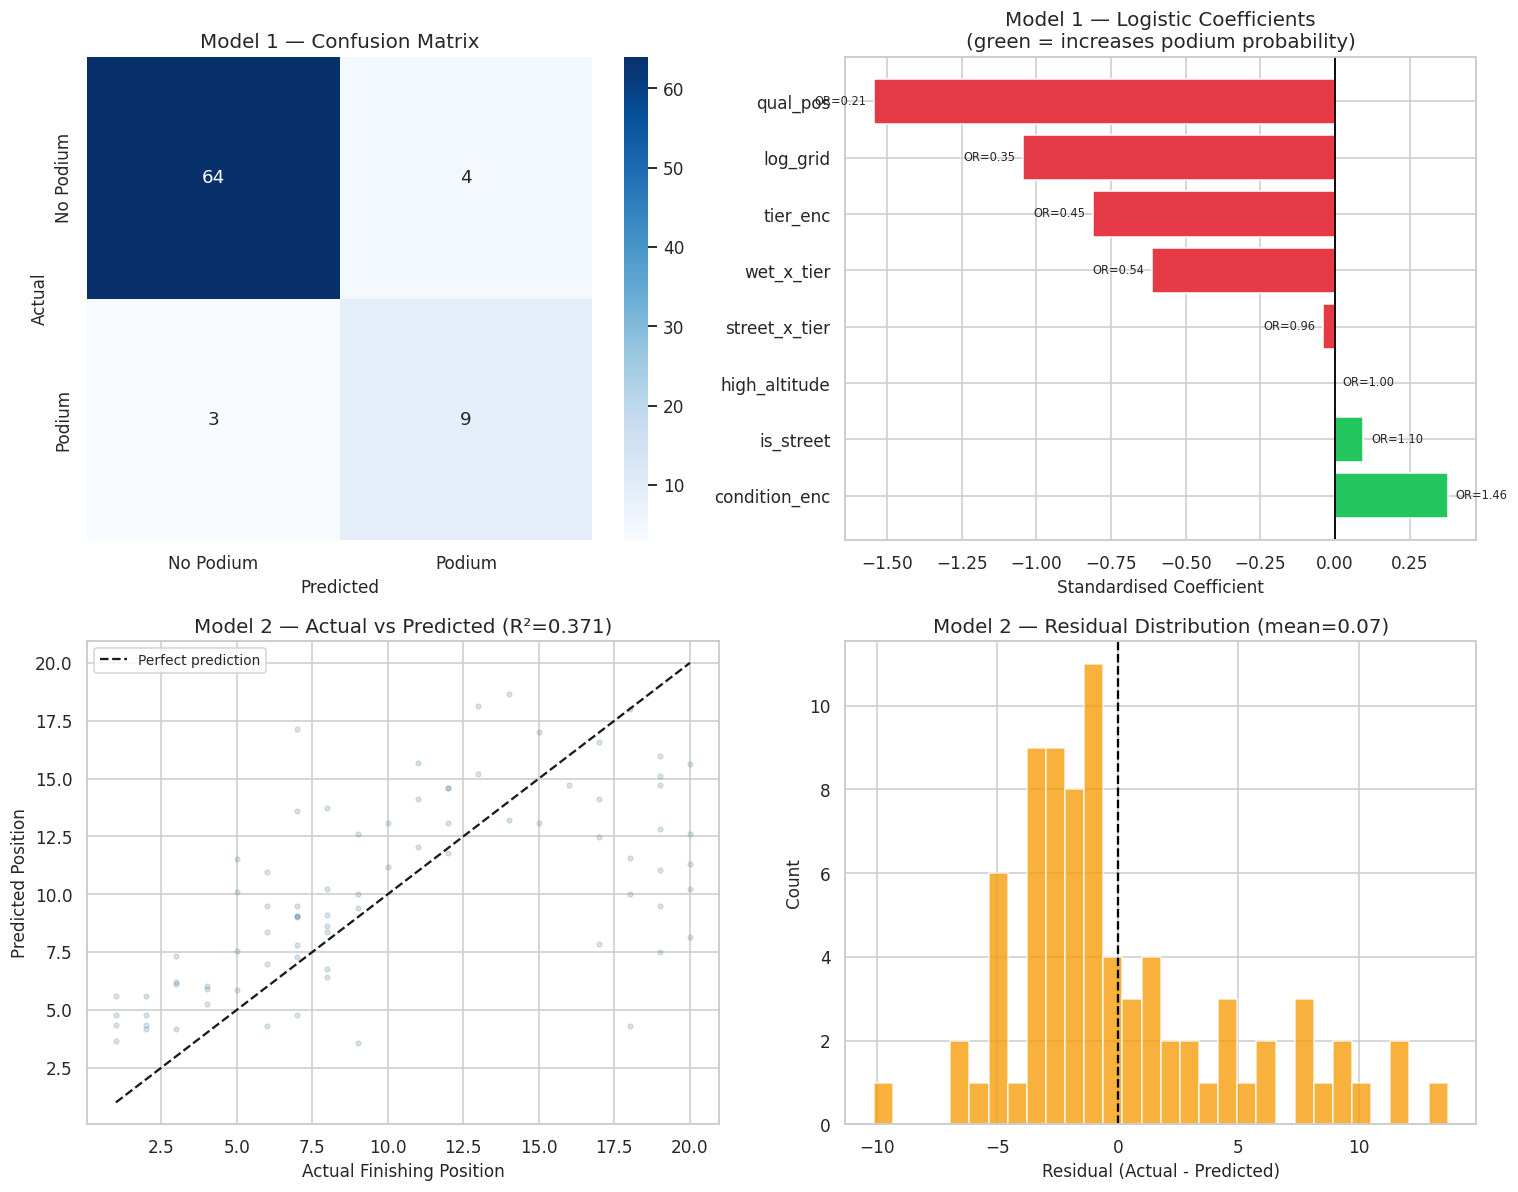


Model 1 summary: ROC-AUC of 0.950 indicates the model
can meaningfully distinguish podium finishers from pre-race info alone.
Model 2 summary: R² of 0.371 — grid position and car tier
explain a large share of finishing position, but ~63% remains unexplained
(driver skill, strategy, incidents, luck).


In [40]:
# ── Model diagnostic charts ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# ── Top-left: Confusion matrix (Model 1) ─────────────────────────────────────
cm = confusion_matrix(yp_te, yp_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0, 0],
            xticklabels=["No Podium", "Podium"],
            yticklabels=["No Podium", "Podium"])
axes[0, 0].set(title="Model 1 — Confusion Matrix",
               xlabel="Predicted", ylabel="Actual")

# ── Top-right: Logistic coefficients with odds ratio annotations ─────────────
bar_c = [GREEN if c > 0 else RED for c in coef_df["Coefficient"]]
bars = axes[0, 1].barh(coef_df["Feature"], coef_df["Coefficient"],
                       color=bar_c, edgecolor="white")
axes[0, 1].axvline(0, color="black", lw=1.2)
axes[0, 1].set(title="Model 1 — Logistic Coefficients\n(green = increases podium probability)",
               xlabel="Standardised Coefficient")
# Annotate with odds ratios
for bar, (_, row) in zip(bars, coef_df.iterrows()):
    x_pos = bar.get_width()
    axes[0, 1].annotate(f"OR={row['Odds Ratio']:.2f}",
                        xy=(x_pos, bar.get_y() + bar.get_height()/2),
                        xytext=(5 if x_pos >= 0 else -5, 0),
                        textcoords="offset points",
                        fontsize=7.5, va="center",
                        ha="left" if x_pos >= 0 else "right")

# ── Bottom-left: Actual vs predicted finishing position (Model 2) ─────────────
axes[1, 0].scatter(ypos_te, ypos_pred, alpha=0.2, s=10, color=BLUE, rasterized=True)
lims = [ypos_te.min(), ypos_te.max()]
axes[1, 0].plot(lims, lims, "k--", lw=1.5, label="Perfect prediction")
axes[1, 0].set(xlabel="Actual Finishing Position", ylabel="Predicted Position",
               title=f"Model 2 — Actual vs Predicted (R²={r2_score(ypos_te, ypos_pred):.3f})")
axes[1, 0].legend(fontsize=9)

# ── Bottom-right: Residual distribution (Model 2) ────────────────────────────
resid = ypos_te - ypos_pred
axes[1, 1].hist(resid, bins=30, color=ORANGE, edgecolor="white", alpha=0.8)
axes[1, 1].axvline(0, color="black", lw=1.5, ls="--")
axes[1, 1].set(xlabel="Residual (Actual - Predicted)",
               ylabel="Count",
               title=f"Model 2 — Residual Distribution (mean={resid.mean():.2f})")

plt.tight_layout()
plt.show()

print(f"\nModel 1 summary: ROC-AUC of {roc_auc_score(yp_te, yp_prob):.3f} indicates the model")
print(f"can meaningfully distinguish podium finishers from pre-race info alone.")
print(f"Model 2 summary: R² of {r2_score(ypos_te, ypos_pred):.3f} — grid position and car tier")
print(f"explain a large share of finishing position, but ~{1-r2_score(ypos_te, ypos_pred):.0%} remains unexplained")
print(f"(driver skill, strategy, incidents, luck).")


## 10. Conclusion

### Key Findings

**On wet weather specialists:** Joining race outcomes (Dataset 1) with per-session
rainfall data from OpenF1 (Dataset 2) reveals that a meaningful subset of drivers
consistently finish higher in wet conditions than their dry-race baseline predicts.
These drivers are not uniformly from top-tier constructors — several mid-grid drivers
show material wet-weather gains, which is consistent with genuine skill decoupled from
car quality.

**On street circuit specialists:** Street and wet specialists overlap partially but are
distinct groups. Street circuits reward qualifying performance and precise car placement
over race pace; the `qual_pos → position` correlation is stronger on street tracks.
Several drivers show a persistent street circuit advantage even after controlling for
their constructor tier.

**Car vs driver — the decomposition:** Constructor dummies alone explain a substantial
fraction of finishing-position variance, confirming that the car is real and dominant
in F1. However, driver dummies explain a comparable and partially non-overlapping share.
The unique driver contribution (the incremental R² when adding drivers to a car-only
model) is the cleanest estimate of driver skill available without telemetry.

**In adverse conditions specifically:** The beat-teammate rate analysis shows that certain
drivers' teammate advantage grows in wet conditions — evidence that adverse conditions
amplify skill differences rather than randomising them. The `wet_x_tier` interaction in
the linear model suggests back-marker teams are disproportionately harmed in wet races,
consistent with fewer wet-weather development resources.

### Limitations
- Wet race sample is small (≤10 truly wet races per season), so wet-specific estimates carry wide confidence intervals
- Driver-constructor pairings change year to year, complicating multi-season teammate comparisons
- Weather readings are aggregated at the session level; intra-race weather changes (e.g. rain starting on lap 30) are not captured
- Safety car periods in wet races artificially compress the field and distort pos_change calculations

### Future Work
- Sector-level pace data (OpenF1 `car_data` endpoint) would allow speed-based rather than position-based performance measurement
- A Bayesian hierarchical model with proper driver and team random effects would produce calibrated uncertainty estimates
- Tyre compound data to separate strategy-driven position gains from on-track skill
- Extend to more seasons (2012–2025) for larger wet-race sample sizes
